### 最小K个数（美团）--排序

给定一个数组nums，设计一个算法，从该数组中寻找最小的k个数。请按从小到大的顺序返回这k个数。

---

### 不同路径（美团）--动态规划

一个机器人位于一个 m x n 网格的左上角 （起始点在下图中标记为 “Start” ）。

机器人每次只能向下或者向右移动一步。机器人试图达到网格的右下角（在下图中标记为 “Finish” ）。

问总共有多少条不同的路径？

---

### 不同路径2--动态规划
给定一个 m x n 的整数数组 grid。一个机器人初始位于 左上角（即 grid[0][0]）。机器人尝试移动到 右下角（即 grid[m - 1][n - 1]）。机器人每次只能向下或者向右移动一步。

网格中的障碍物和空位置分别用 1 和 0 来表示。机器人的移动路径中不能包含 任何 有障碍物的方格。

返回机器人能够到达右下角的不同路径数量。

测试用例保证答案小于等于 2 * 109。

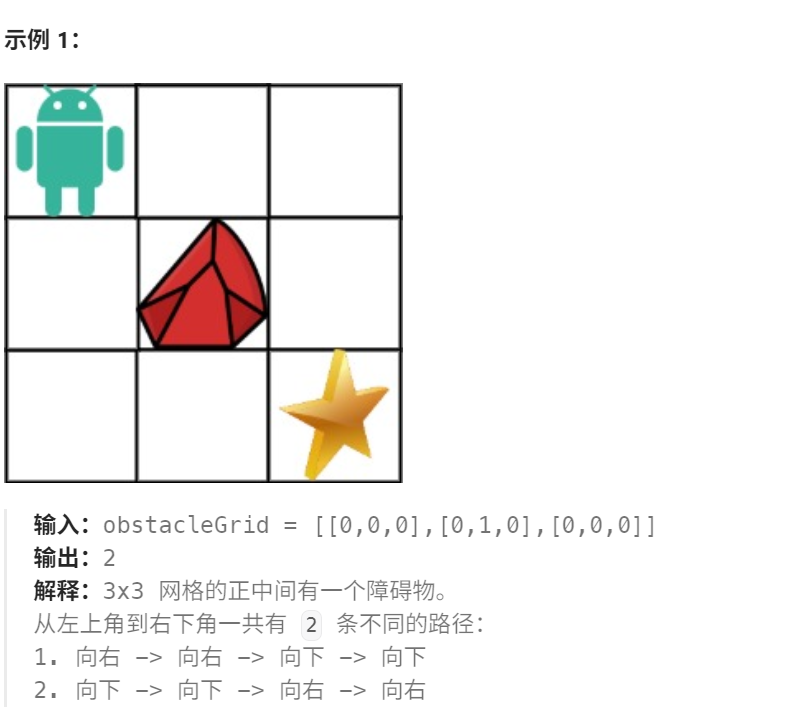

---

### 乘积最大子数组（快手）
给你一个整数数组 nums ，请你找出数组中乘积最大的非空连续 子数组（该子数组中至少包含一个数字），并返回该子数组所对应的乘积

---

### 数组中的第K个最大元素--快速选择

给定整数数组 nums 和整数 k，请返回数组中第 k 个最大的元素。

请注意，你需要找的是数组排序后的第 k 个最大的元素，而不是第 k 个不同的元素。

你必须设计并实现时间复杂度为 O(n) 的算法解决此问题。

---

### 会议室2（腾讯PCG）

给你一个会议时间安排的数组 intervals ，每个会议时间都会包括开始和结束的时间 intervals[i] = [starti, endi] ，返回 所需会议室的最小数量 。
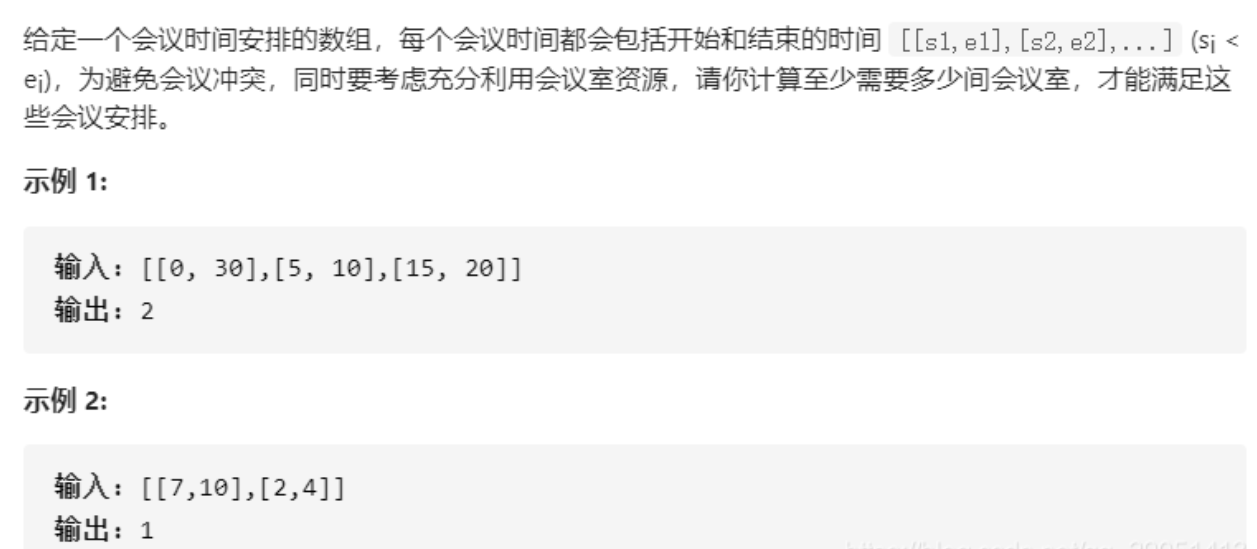

核心思路：
本质是求区间集合在任意时刻的最大重叠数——即同时处于"开始但尚未结束"状态的区间数量的峰值。

算法直觉：
将问题转化为"会议室资源调度"：

- 贪心思想：当新会议到来时，优先复用最早结束的会议室。若其结束时间 ≤ 新会议开始时间，则腾出该房间供复用；否则必须新开一间。

- 最小堆维护"最早结束时间"：堆顶始终是当前所有占用会议室中最早空闲的那个，O(log n) 完成插入与弹出。

In [10]:
import heapq

class Solution:
    def minMeetingRooms(self, intervals):
        """
        目标：给定一组会议 [start, end)，求最少需要多少间会议室（同一时刻 end==start 不冲突）。
        方法：最小堆（小根堆）按“结束时间”管理当前在开的会议；堆大小即并发会议数。
        """
        if not intervals:
            return 0
        # 1) 先按开始时间排序，保证按时间线从早到晚处理
        intervals.sort(key=lambda x: x[0])
        heap = []
        max_rooms = 0
        # 2) 若前面会议的结束时间小于等于下一场会议开始的时间，则可共用一间会议室
        for s, e in intervals:
            while heap and heap[0] <= s:
                heapq.heappop(heap)
            heapq.heappush(heap, e) # 放在最前面，该会议结束时间一定是最早的
            max_rooms = max(max_rooms, len(heap))

        return max_rooms
test = [[0, 30], [5, 10], [15, 20]]
print(Solution().minMeetingRooms(test))

2


时间O(n log n)：
- 排序 O(n log n)；
- 每个区间各执行一次 push + 至多一次 pop，单次操作 O(log n)，共 O(n log n)

空间：O(n)；
最坏情况（所有会议完全重叠）堆中存放 n 个结束时间

---

### 解码方法（腾讯PCG）

一条包含字母 A-Z 的消息通过以下映射进行了 编码 ：

"1" -> 'A'

"2" -> 'B'

...

"25" -> 'Y'

"26" -> 'Z'

然而，在 解码 已编码的消息时，你意识到有许多不同的方式来解码，因为有些编码被包含在其它编码当中（"2" 和 "5" 与 "25"）。

例如，"11106" 可以映射为：

"AAJF" ，将消息分组为 (1, 1, 10, 6)

"KJF" ，将消息分组为 (11, 10, 6)

消息不能分组为  (1, 11, 06) ，因为 "06" 不是一个合法编码（只有 "6" 是合法的）。
注意，可能存在无法解码的字符串。

给你一个只含数字的 非空 字符串 s ，请计算并返回 解码 方法的 总数 。如果没有合法的方式解码整个字符串，返回 0。

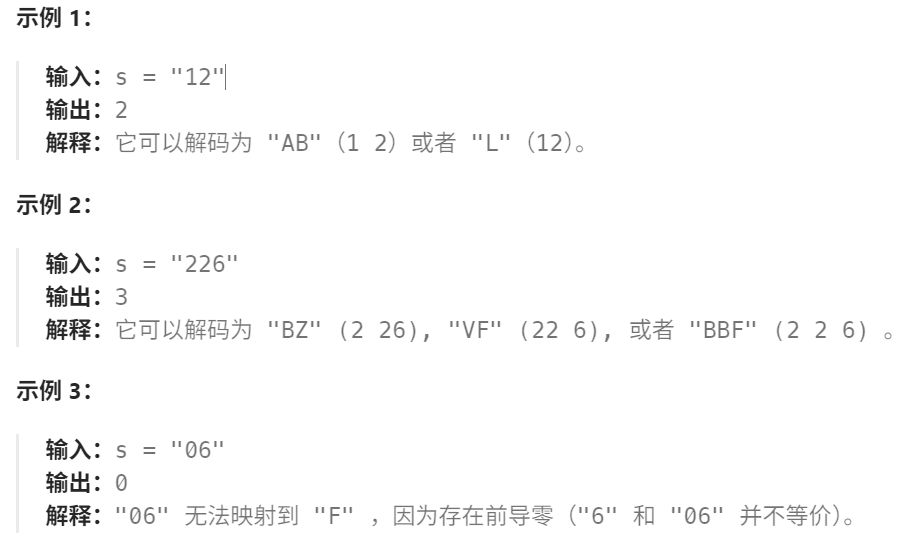

核心思想
加入的元素，分为两种情况，可以单独编码吗？可以组合编码吗？互相不冲突

- （1）当加入的一个数不是0，他一定可以单独编码，那么至少 dp i= dpi_1。
- （2）当加入的一个数可以与前面的组合编码，那么至少 dpi = dpi_2

In [3]:
class Solution:
    def numDecodings(self, s: str) -> int:
        n = len(s)
        if  not s or s[0] == '0':
            return 0

        dpi_2, dpi_1 = 1, 1
        
        for i in range(1, n):
            dpi = 0
            if s[i] != '0':
                dpi = dpi_1
            if s[i-1] == '1' or (s[i-1] == '2' and s[i] < '7'):
                dpi += dpi_2
            if dpi == 0:
                return 0
            dpi_2, dpi_1 = dpi_1, dpi

        return dpi_1
s = "238"
print(Solution().numDecodings(s))

2


### 二叉树节点染色的最大权值问题(字节国际电商)
给定一个整数数组 nums，用来按层序（level order）表示一棵二叉树。

数组规则如下：

nums[i] 表示编号为 i 的节点的权重。

若 nums[i] 为 null（或某特殊标记），表示该位置不存在节点。

对于任意下标 i：

左子节点下标为 2*i + 1

右子节点下标为 2*i + 2

若子节点下标越界或该位置为 null，则该子节点不存在。

现在你可以对若干节点进行“染色”。

染色约束：

若某节点被染色，则它的父节点不能被染色；

若某节点被染色，则它的左右子节点不能被染色；

兄弟节点之间没有限制。

目标：

在满足上述约束的前提下，选择若干节点，使得被染色节点的权重之和最大。

返回这个最大值。

核心思路

假设：

left = (L0, L1)
right = (R0, R1)

那么：

L0 = 不选左孩子时的最大值
L1 = 选左孩子时的最大值
R0 = 不选右孩子时的最大值
R1 = 选右孩子时的最大值

状态转移

情况1：选当前节点

如果你选当前节点：

那么左右孩子都不能选。

所以：

choose = 当前权重 + L0 + R0

因为：

只能拿“不选孩子”的值。

情况2：不选当前节点

如果你不选当前节点：

左右孩子可以自由选择（选或不选）

所以：

not_choose = max(L0, L1) + max(R0, R1)

In [1]:
from typing import List, Optional

class Solution:
    def maxColorValue(self, nums: List[Optional[int]]) -> int:
        n = len(nums)
        def dfs(i: int):
            """
            返回:
            (not_choose, choose)
            not_choose: 不选当前节点的最大值
            choose: 选当前节点的最大值
            """
            
            # 越界 或 节点为空
            if i >= n or nums[i] is None:
                return (0, 0)
            
            # 递归计算左右子节点
            left = dfs(2 * i + 1)
            right = dfs(2 * i + 2)
            
            # 选当前节点
            # 子节点必须不选
            choose = nums[i] + left[0] + right[0]
            
            # 不选当前节点
            # 子节点可以选或不选，取最大
            not_choose = max(left) + max(right)
            
            return (not_choose, choose)
        
        # 根节点开始
        result = dfs(0)
        
        # 最终可以选根，也可以不选根
        return max(result)
nums = [3,2,3,None,3,None,1]
print(Solution().maxColorValue(nums))

7


---

### 代码infoNCE的函数计算公式（字节国际电商，主播自己项目所用）

In [30]:
import torch
import torch.nn.functional as F
def infoNCE(user_emb, item_emb, tempreture = 0.5):
    B, D = user_emb.shape
    # 归一化
    user_emb = F.normalize(user_emb, dim = -1)
    item_emb = F.normalize(item_emb, dim = -1)
    # 相似矩阵
    sim = torch.matmul(user_emb, item_emb.transpose(0, 1)) / tempreture
    # 标签
    label = torch.arange(B)
    # 多类交叉熵计算
    loss = F.cross_entropy(sim, label) # Compute the cross entropy loss between input logits and target.
    return loss
user_emb = torch.tensor([[1.1, 24.0, 5.9], [3.3, 9.2, 32.1], [12.1, 11.1, 15.3], [0.8, 0.1, 0.4]])
item_emb = torch.tensor([[1.1, 24.0, 5.9], [3.3, 9.2, 32.1], [12.1, 11.1, 15.3], [0.8, 0.1, 0.4]])
print(infoNCE(user_emb, item_emb, 1))

tensor(1.1176)


In [ ]:
import torch
import torch.nn.functional as F
def cross_entropy(logits, labels):
    B, _ = logits.shape
    max_logits = torch.max(logits, dim=-1, keepdim=True)[0] #返回（最大值数值，最大值的位置索引），取[0]表示取出最大值
    stable_logits = logits - max_logits     # B, D
    log_sum_exp = torch.log(torch.sum(torch.exp(stable_logits), dim=-1))    #(B,)
    pos_logits = stable_logits[torch.arange(B), labels]     # (B,)
    loss = - pos_logits + log_sum_exp
    return loss.mean()

def infoNCE(user_emb, item_emb, tempreture=0.7):
    B, D = user_emb.shape
    user_emb = F.normalize(user_emb, dim=-1)
    item_emb = F.normalize(item_emb, dim=-1)
    sim = torch.matmul(user_emb, item_emb.transpose(0,1)) / tempreture
    label = torch.arange(B)
    loss = cross_entropy(sim, label)
    return loss
user_emb = torch.tensor([[1.1, 24.0, 5.9], [3.3, 9.2, 32.1], [12.1, 11.1, 15.3], [0.8, 0.1, 0.4]])
item_emb = torch.tensor([[1.1, 24.0, 5.9], [3.3, 9.2, 32.1], [12.1, 11.1, 15.3], [0.8, 0.1, 0.4]])
print(infoNCE(user_emb, item_emb, 1))

tensor(1.1176)


---

### 121. 买卖股票的最佳时机(字节)

给定一个数组 prices ，它的第 i 个元素 prices[i] 表示一支给定股票第 i 天的价格。

你只能选择 某一天 买入这只股票，并选择在 未来的某一个不同的日子 卖出该股票。设计一个算法来计算你所能获取的最大利润。

返回你可以从这笔交易中获取的最大利润。如果你不能获取任何利润，返回 0 

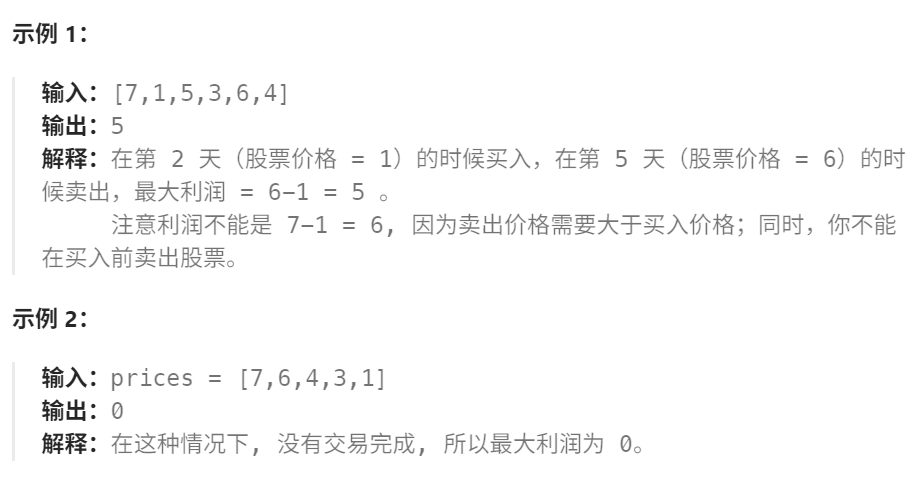


核心思想

在遍历到第 i 天时，
假设第 i 天卖出，最大利润是多少？

利润 = 当前价格 − 之前某一天的最低价格

因此算法维护两个量：

cur_min_price：到当前为止出现过的最低价格（即最优买入点）。

max_profit：到当前为止能获得的最大利润。

一次遍历 + 动态维护历史最低价。


In [2]:
from typing import List
class Solution:
    def maxProfit(self, prices: List[int]) -> int:
        n = len(prices)
        cur_min_price = prices[0]
        max_profit = 0
        for i in range(1, n):
            cur_min_price = min(cur_min_price, prices[i])
            max_profit = max(max_profit, prices[i] - cur_min_price)
        return max_profit
prices = [7, 1, 5, 3, 6, 4]
print(Solution().maxProfit(prices))

5


时间复杂度 O(n)

空间复杂度 O(1)

---

## 105. 岛屿的最大面积(腾讯WXG)

给定一个由 0 和 1 组成的非空二维数组 grid ，用来表示海洋岛屿地图。

一个 岛屿 是由一些相邻的 1 (代表土地) 构成的组合，这里的「相邻」要求两个 1 必须在水平或者竖直方向上相邻。你可以假设 grid 的四个边缘都被 0（代表水）包围着。

找到给定的二维数组中最大的岛屿面积。如果没有岛屿，则返回面积为 0 。

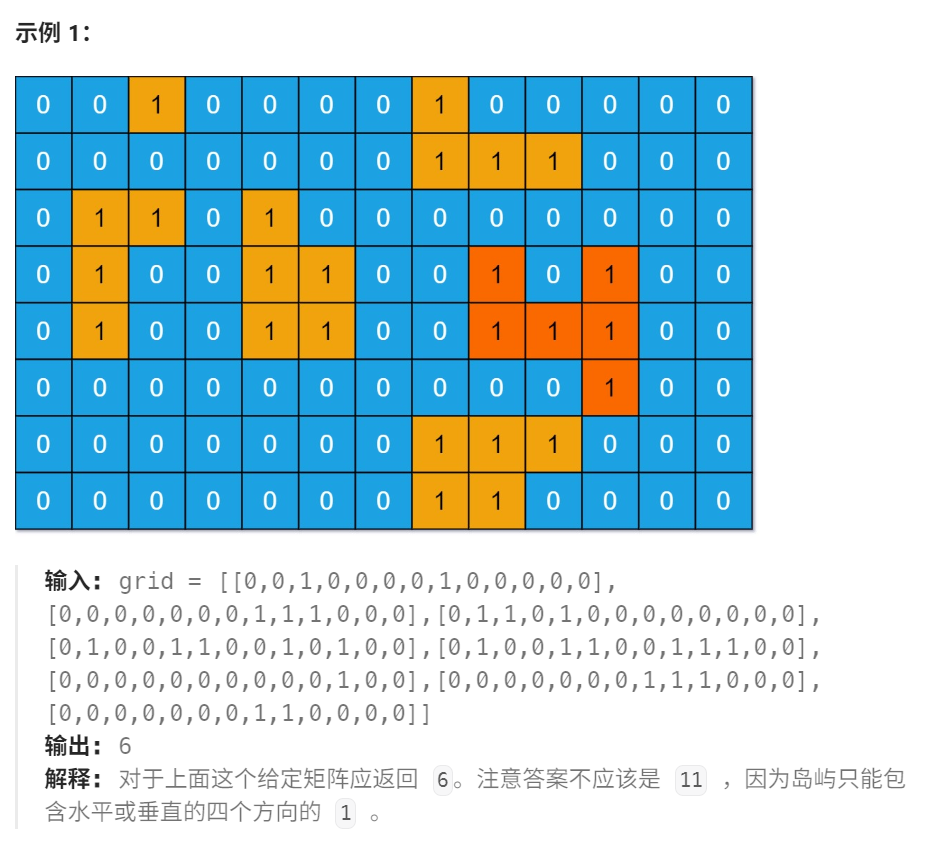

这是一个典型的二维网格 DFS / BFS 遍历问题。本质是：
遍历每个位置，遇到 1 时，向四个方向扩散，把整块连通区域面积统计出来，并取最大值。

核心思想：

1. 外层双重循环遍历整个 grid
2. 遇到 1 时启动 DFS
3. DFS 负责：

   * 累加面积
   * 把访问过的 1 置为 0（避免重复访问）
   * 向四个方向继续扩散


In [16]:
from typing import List

class Solution:
    def maxAreaOfIsland(self, grid: List[List[int]]) -> int:
        
        if not grid or not grid[0]:
            return 0
        
        rows = len(grid)
        cols = len(grid[0])
        max_area = 0
        
        # 定义 DFS
        def dfs(r: int, c: int) -> int:
            # 越界 或 当前是水，返回 0
            if r < 0 or r >= rows or c < 0 or c >= cols or grid[r][c] == 0:
                return 0
            
            # 访问过的陆地置为 0，避免重复访问
            grid[r][c] = 0
            
            # 当前格子面积为 1
            area = 1
            
            # 向四个方向扩散
            area += dfs(r + 1, c)
            area += dfs(r - 1, c)
            area += dfs(r, c + 1)
            area += dfs(r, c - 1)
            
            return area
        
        # 遍历每一个位置
        for i in range(rows):
            for j in range(cols):
                if grid[i][j] == 1:
                    # 每次发现新岛屿，计算面积
                    current_area = dfs(i, j)
                    max_area = max(max_area, current_area)
        
        return max_area
grid = [
        [1, 1, 0, 0, 1, 1],
        [1, 1, 1, 0, 1, 1],
        [0, 1, 1, 0, 1, 0]
        ]
print(Solution().maxAreaOfIsland(grid))   

7


时间复杂度：

O(m × n)

每个格子最多被访问一次。

空间复杂度：

O(m × n)（最坏情况下递归栈深度为整个网格大小，例如全是 1）

如果是正常岛屿分布，递归深度通常为单个岛屿面积。

---

## 200. 岛屿数量

给你一个由 '1'（陆地）和 '0'（水）组成的的二维网格，请你计算网格中岛屿的数量。

岛屿总是被水包围，并且每座岛屿只能由水平方向和/或竖直方向上相邻的陆地连接形成。

此外，你可以假设该网格的四条边均被水包围。

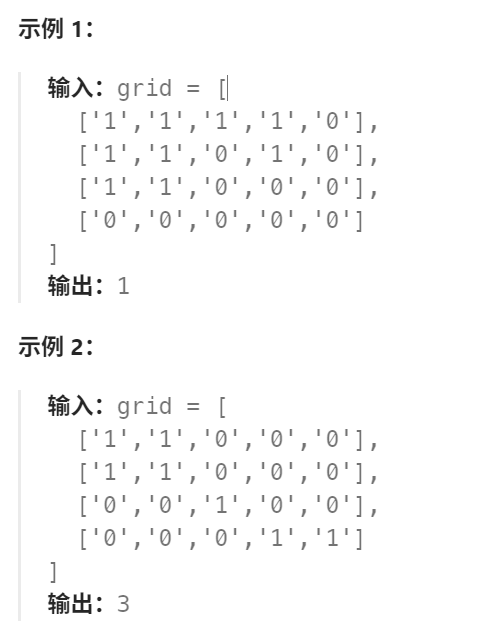

In [ ]:
from typing import List

class Solution:
    def numIslands(self, grid: List[List[str]]) -> int:
        
        if not grid or not grid[0]:
            return 0
        
        rows = len(grid)
        cols = len(grid[0])
        count = 0
        
        def dfs(r: int, c: int) -> None:
            # 越界 或 当前是水，直接返回
            if r < 0 or r >= rows or c < 0 or c >= cols or grid[r][c] == "0":
                return
            
            # 淹掉当前陆地
            grid[r][c] = "0"
            
            # 扩散四个方向
            dfs(r + 1, c)
            dfs(r - 1, c)
            dfs(r, c + 1)
            dfs(r, c - 1)
        
        for i in range(rows):
            for j in range(cols):
                if grid[i][j] == "1":
                    count += 1   # 发现一个新岛屿
                    dfs(i, j)    # 把整座岛淹掉
        
        return count

时间复杂度：

O(m × n)

每个格子最多访问一次。

空间复杂度：

O(m × n)

最坏情况递归深度为整个网格。

---

## 最长公共子序列，输出公共子序列（字节国际电商）
给定两个字符串 text1 和 text2，请返回它们的最长公共子序列（Longest Common Subsequence, LCS）。

如果不存在公共子序列，返回空字符串 ""。

说明：

子序列是指在不改变字符相对顺序的情况下，通过删除某些字符（或不删除）得到的新字符串。

一个字符串的子序列可以是该字符串本身。

如果存在多个最长公共子序列，返回其中任意一个即可。

示例：

输入：
text1 = "abcde"
text2 = "ace"

输出：
"ace"

核心思想：

需要用到输出最长公共子序列长度

1）DP 表记录的是“最优值结构”

2）回溯是在“最优值结构”上反向找路径
- 当字符相等时，一定来自左上角。
- 当字符不等时，一定来自上或左，选值更大的方向。

In [19]:
class Solution:
    def longestCommonSubsequence(self, text1: str, text2: str) -> str:
        m, n = len(text1), len(text2)
        # dp[i][j] 表示 text1[:i] 和 text2[:j] 的 LCS 长度
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        print(dp)
        # 1. 先计算长度
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                
                if text1[i - 1] == text2[j - 1]:
                    dp[i][j] = dp[i - 1][j - 1] + 1
                else:
                    dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
        # 2. 回溯构造字符串
        print(dp)
        i, j = m, n
        res = []
        while i > 0 and j > 0:
            # 当前字符相同，说明一定在 LCS 里
            if text1[i - 1] == text2[j - 1]:
                res.append(text1[i - 1])
                i -= 1
                j -= 1
            # 否则看是从哪里转移过来的
            elif dp[i - 1][j] >= dp[i][j - 1]:
                i -= 1
            else:
                j -= 1
        # 因为是从后往前加的，需要反转
        return ''.join(reversed(res))

text1 = "abcde"
text2 = "ace"
print(Solution().longestCommonSubsequence(text1, text2))

[[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]
[[0, 0, 0, 0], [0, 1, 1, 1], [0, 1, 1, 1], [0, 1, 2, 2], [0, 1, 2, 2], [0, 1, 2, 3]]
ace
